# Enterprise Company Knowledge RAG

This project using:
- Python
- OpenAI Embeddings
- Pinecone
- Pinecone Metadata Filtering
- Pinecone Reranking
- OpenAI Responses API
- PDF processing
- Chunking
- Citations
- Retrieval evaluation
- Role-based document access

## Project Structure

```text
company-knowledge-rag/
│
├── documents/
│   ├── README.md
│   └── Your PDF files go here
│
├── evaluation/
│   └── evaluation.json
│
├── config.py
├── document_config.py
├── ingest.py
├── rag.py
├── evaluate.py
│
├── requirements.txt
├── .env.example
├── .gitignore
└── README.md
```

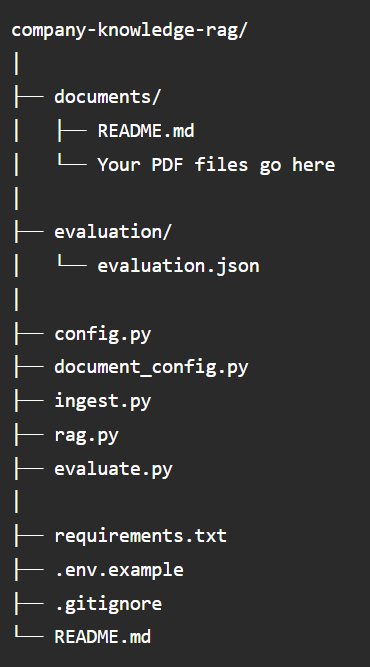

## Enterprise Architecure

```text
                    ┌─────────────────────┐
                    │ Company PDF Files   │
                    │                     │
                    │ employee_handbook   │
                    │ IT_policy           │
                    │ security_policy     │
                    │ leave_policy        │
                    │ onboarding          │
                    └──────────┬──────────┘
                               │
                               ▼
                    ┌─────────────────────┐
                    │ Document Processing │
                    │                     │
                    │ PDF Loader          │
                    │ Text Extraction     │
                    │ Cleaning            │
                    │ Metadata            │
                    └──────────┬──────────┘
                               │
                               ▼
                    ┌─────────────────────┐
                    │ Chunking            │
                    │                     │
                    │ 300-500 tokens      │
                    │ overlap 50 tokens   │
                    └──────────┬──────────┘
                               │
                               ▼
                    ┌─────────────────────┐
                    │ Embedding Model     │
                    │                     │
                    │ text → vector       │
                    └──────────┬──────────┘
                               │
                               ▼
                    ┌─────────────────────┐
                    │ Pinecone            │
                    │                     │
                    │ Vector              │
                    │ Metadata            │
                    └──────────┬──────────┘
                               │
                       User Question
                               │
                               ▼
                    ┌─────────────────────┐
                    │ Query Embedding     │
                    └──────────┬──────────┘
                               │
                               ▼
                    ┌─────────────────────┐
                    │ Metadata Filtering  │
                    └──────────┬──────────┘
                               │
                               ▼
                    ┌─────────────────────┐
                    │ Vector Search       │
                    │ top_k = 20          │
                    └──────────┬──────────┘
                               │
                               ▼
                    ┌─────────────────────┐
                    │ Reranker            │
                    │ top 20 → top 5      │
                    └──────────┬──────────┘
                               │
                               ▼
                    ┌─────────────────────┐
                    │ Prompt Construction │
                    └──────────┬──────────┘
                               │
                               ▼
                    ┌─────────────────────┐
                    │ LLM                 │
                    └──────────┬──────────┘
                               │
                               ▼
                    ┌─────────────────────┐
                    │ Answer + Citations  │
                    └─────────────────────┘
```

## Document Configuration

The project contains:
document_config.py
This file defines document metadata and access permissions.

For example:
```python
DOCUMENT_CONFIG = {
    "leave_policy.pdf": {
        "document_type": "leave_policy",
        "department": "HR",
        "version": "2026.1",
        "allowed_roles": [
            "employee",
            "hr_manager",
            "it_admin",
            "security_admin"
        ],
    }
}
```

This means:
```text
leave_policy.pdf
       │
       ├── Department: HR
       ├── Version: 2026.1
       └── Allowed Roles:
              ├── employee
              ├── hr_manager
              ├── it_admin
              └── security_admin
```

# Document Processing

The ingestion pipeline is:
```text
PDF
 ↓
PDF Loader
 ↓
Page
 ↓
Text Extraction
 ↓
Chunking
 ↓
Metadata
 ↓
Embedding
 ↓
Pinecone
```

For example:
```text
leave_policy.pdf
       ↓
Page 1
Page 2
Page 3
       ↓
Chunks
       ↓
Embeddings
       ↓
Pinecone
```

## Load pdf

In [2]:
# ingest.py

from pathlib import Path

from pypdf import PdfReader


def load_pdf(pdf_path: str) -> list[dict]:
    reader = PdfReader(pdf_path)

    documents = []

    for page_number, page in enumerate(reader.pages, start=1):
        text = page.extract_text() or ""
        text = text.strip()

        if not text:
            continue

        documents.append(
            {
                "text": text,
                "page": page_number,
                "source": Path(pdf_path).name,
            }
        )

    return documents

### test

In [ ]:
from config import TEST_PDF_PATH

pages = load_pdf(TEST_PDF_PATH)
print(pages[0])

## Chunking

The system does not store the entire PDF as one vector.

The project uses:
```python
CHUNK_SIZE=100
CHUNK_OVERLAP=20
```

The purpose of overlap is to avoid losing context between two chunks.

In [3]:
# ingest.py
def chunk_text(text: str, chunk_size: int = 100, overlap: int = 20) -> list[str]:
    words = text.split()
    chunks = []
    start = 0

    while start < len(words):
        end = start + chunk_size
        chunk = " ".join(words[start:end])
        chunks.append(chunk)
        start += chunk_size - overlap

    return chunks

### test

In [3]:
# test
text = """
Full-time employees receive 20 days of annual leave
per year. Employees should submit leave requests
through the HR system.
"""

chunks = chunk_text(text)

for chunk in chunks:
    print(chunk)

Full-time employees receive 20 days of annual leave per year. Employees should submit leave requests through the HR system.


## Add Metadata

Every chunk contains metadata.
```python
{
    "source": "leave_policy.pdf",
    "page": 3,
    "chunk_number": 0,
    "document_id": "leave_policy",
    "document_type": "leave_policy",
    "department": "HR",
    "version": "2026.1",
    "allowed_roles": [
        "employee",
        "hr_manager",
        "it_admin",
        "security_admin"
    ],
    "text": "Full-time employees receive 20 days..."
}
```

The vector is used for Semantic Search.
The metadata is used for:
```text
Security
Filtering
Traceability
Versioning
Citations
```

In [ ]:
# test
# from config import DOCUMENT_CONFIG, TEST_PDF_PATH

# pdf_name = Path(TEST_PDF_PATH).name
# print(DOCUMENT_CONFIG[pdf_name])

{'document_type': 'leave_policy', 'department': 'HR', 'version': '2026.1', 'allowed_roles': ['employee', 'hr_manager', 'it_admin', 'security_admin']}


In [6]:
from config import CHUNK_OVERLAP, CHUNK_SIZE, DOCUMENT_CONFIG


def create_chunks(pdf_path: str) -> list[dict]:

    pdf_name = Path(TEST_PDF_PATH).name
    document_type = DOCUMENT_CONFIG[pdf_name]["document_type"]
    department = DOCUMENT_CONFIG[pdf_name]["department"]
    allowed_roles = DOCUMENT_CONFIG[pdf_name]["allowed_roles"]
    version = DOCUMENT_CONFIG[pdf_name]["version"]

    pages = load_pdf(pdf_path)

    results = []

    for page in pages:
        chunks = chunk_text(
            page["text"],
            chunk_size=CHUNK_SIZE,
            overlap=CHUNK_OVERLAP,
        )

        for index, chunk in enumerate(chunks, start=1):
            results.append(
                {
                    "text": chunk,
                    "metadata": {
                        "source": page["source"],
                        "page": page["page"],
                        "chunk_id": index,
                        "document_type": document_type,
                        "department": department,
                        "allowed_roles": allowed_roles,
                        "version": version,
                    },
                }
            )

    return results

### test

In [7]:
chunks = create_chunks("documents/leave_policy.pdf")
print(chunks[0])

{'text': "Southern Cross Technology Pty Ltd Page 1 Leave Policy Guidance for annual leave, personal/carer's leave, compassionate leave and other approved absences. Internal Company Document | Version 1.0 | Effective: 1 September 2026 1. General Principles \x7f Employees should request planned leave as early as practical so teams can manage workload and coverage. \x7f Leave approval is subject to applicable employment conditions, operational requirements and relevant Australian workplace law. \x7f The HR system is the source of record for approved leave balances and requests. 2. Annual Leave \x7f Full-time and part-time employees accrue annual leave according to their applicable employment conditions.", 'metadata': {'source': 'leave_policy.pdf', 'page': 1, 'chunk_id': 1, 'document_type': 'leave_policy', 'department': 'HR', 'allowed_roles': ['employee', 'hr_manager', 'it_admin', 'security_admin'], 'version': '2026.1'}}


# Embedding

The project uses embedding model:
text-embedding-3-small

The pipeline is:
```text
Text
 ↓
Embedding Model
 ↓
Vector
```

The user's question is also converted into a vector.
Then Pinecone searches for semantically similar vectors.

In [8]:
from config import EMBEDDING_MODEL
from openai import OpenAI

client = OpenAI()


def create_embedding(text: str) -> list[float]:
    response = client.embeddings.create(
        model=EMBEDDING_MODEL,
        input=text,
    )

    return response.data[0].embedding

### test

In [27]:
# test
vector = create_embedding("How many days of annual leave do employees receive?")

print(len(vector))

1536


# Pinecone

The project automatically creates the Pinecone index if it does not already exist.

The defalut configuration is:
```text
Index:
company-knowledge-rag

Dimension:
1536

Metric:
cosine
```

The dimension must match the embedding model.
A Pinecone recore looks conceptually like:
```python
{
    "id": "leave_policy#page-0003#chunk-0000",

    "values": [...],

    "metadata": {
        "source": "leave_policy.pdf",
        "page": 3,
        "document_type": "leave_policy",
        "department": "HR",
        "version": "2026.1",
        "allowed_roles": [
            "employee",
            "hr_manager",
            "it_admin",
            "security_admin"
        ],
        "text": "Full-time employees receive 20 days..."
    }
}
```

In [9]:
from config import PINECONE_INDEX_NAME
from pinecone import Pinecone, ServerlessSpec

pc = Pinecone()

## Check the index is existed

In [12]:
def is_existed_index(index_name: str, pc: Pinecone) -> bool:
    result = False
    pinecone_indexes = pc.list_indexes()

    for index in pinecone_indexes:
        if index.name == index_name:
            return True

    return result


print(is_existed_index(index_name=PINECONE_INDEX_NAME, pc=pc))

False


## Create the index "company-knowledge-rag"

In [13]:
if not is_existed_index(index_name=PINECONE_INDEX_NAME, pc=pc):
    # Create your Pinecone index
    pc.create_index(
        name=PINECONE_INDEX_NAME,
        dimension=1536,
        spec=ServerlessSpec(
            cloud="aws",
            region="us-east-1",
        ),
    )

index = pc.Index(PINECONE_INDEX_NAME)

# Print the index statistics
print(index.describe_index_stats())

DescribeIndexStatsResponse(dimension=1536, total_vector_count=0, metric='cosine', namespaces=0)


## Upload DATA to Pinecone

In [ ]:
# print(len(chunks))
# print(chunks[0]["metadata"])
# length = len(str(abs(len(chunks))))
# print(length)

1


### 12. Deterministic Vector IDs

The project intentionally uses deterministic IDs:
```text
document#page#chunk
```

For example:
```text
leave_policy#page-0003#chunk-0000
```

This is better than generating a random UUID every time.
The same document chunks can be updated rather than creating a completely new set of random records.
This is useful for production ingestion pipelines.

In [14]:
def generate_deterministic_vector_id(chunk, chunks_length) -> str:

    document = Path(chunk["metadata"]["source"]).stem
    page = str(chunk["metadata"]["page"]).zfill(chunks_length)
    chunk_id = str(chunk["metadata"]["chunk_id"]).zfill(chunks_length)
    return f"{document}#page-{page}#chunk-{chunk_id}"


print(generate_deterministic_vector_id(chunks[0], 4))  # test

leave_policy#page-0001#chunk-0001


In [15]:
def upload_chunks(chunks: list[dict]):

    vectors = []
    chunks_length = len(chunks)

    for chunk in chunks:
        vector = create_embedding(chunk["text"])
        vector_id = generate_deterministic_vector_id(chunk, chunks_length)

        vectors.append(
            {
                "id": vector_id,
                "values": vector,
                "metadata": {
                    **chunk["metadata"],
                    "text": chunk["text"],
                },
            }
        )

    index.upsert(vectors=vectors)


### test

In [13]:
# test
chunks = create_chunks(TEST_PDF_PATH)
upload_chunks(chunks)

## Upload whole documents folder

In [16]:
documents_dir = Path("documents")

for pdf_path in documents_dir.glob("*.pdf"):
    print(f"Processing {pdf_path.name}")
    chunks = create_chunks(str(pdf_path))
    upload_chunks(chunks)
    print(f"Uploaded {len(chunks)} chunks")

Processing employee_handbook.pdf
Uploaded 6 chunks
Processing IT_policy.pdf
Uploaded 6 chunks
Processing leave_policy.pdf
Uploaded 5 chunks
Processing onboarding.pdf
Uploaded 6 chunks
Processing security_policy.pdf
Uploaded 6 chunks


# Security

This is one of the most important parst of the project.

The user has a role:
employee, hr_manager, it_admin, security_admin

Before retrieval, the system builds a Pinecone metadata filter:
```python
{
    "allowed_roles": {
        "$in": ["employee"]
    }
}
```

The retrieval pipeline becomes:
```text
User
 ↓
Authentication
 ↓
Authorization
 ↓
Metadata Filter
 ↓
Pinecone
 ↓
Allowed Documents
 ↓
Reranking
 ↓
LLM
```

Security should be enforced before the documents reach the LLM.
Prompt instructions are not a replacement for authorization.

# Retrieval

## Query similarity

In [17]:
question = "How many days of annual leave do employee receive?"

query_vector = create_embedding(question)

result = index.query(
    vector=query_vector,
    top_k=10,
    include_metadata=True,
)

for match in result["matches"]:
    print(
        match["score"],
        match["metadata"]["source"],
        match["metadata"]["page"],
    )

0.605297506 leave_policy.pdf 1
0.514539301 leave_policy.pdf 1
0.482880503 leave_policy.pdf 1
0.434916347 leave_policy.pdf 1
0.391218573 leave_policy.pdf 2
0.353849471 employee_handbook.pdf 1
0.279914528 employee_handbook.pdf 1
0.268125921 employee_handbook.pdf 1
0.263282239 onboarding.pdf 1
0.256389588 onboarding.pdf 1


## Metadata Filtering

In [19]:
user_role = "employee"

results = index.query(
    vector=query_vector,
    top_k=20,
    include_metadata=True,
    filter={"allowed_roles": {"$eq": user_role}},
)

print(results["matches"][:2])

[ScoredVector(id='leave_policy#page-00001#chunk-00002', score=0.605297506, values=[], metadata={'allowed_roles': ['employee', 'hr_manager', 'it_admin', 'security_admin'], 'chunk_id': 2, 'department': 'HR', 'document_type': 'leave_policy', 'page': 1, 'source': 'leave_policy.pdf', 'text': "balances and requests. 2. Annual Leave \x7f Full-time and part-time employees accrue annual leave according to their applicable employment conditions. \x7f Employees should submit planned annual leave through the HR system before making non-refundable travel arrangements. \x7f Managers consider team coverage, business needs and the employee's accrued balance when reviewing requests. 3. Personal and Carer's Leave \x7f Personal/carer's leave may be used when an employee is unfit for work because of illness or injury, or when the employee needs to provide care or support to an eligible family or household member. \x7f Employees should notify their manager as soon as", 'version': '2026.1'}), ScoredVector(i

## Retrieval Function

In [20]:
def retrieve_documents(
    question: str,
    user_role: str,
    top_k: int = 20,
):
    query_vector = create_embedding(question)
    results = index.query(
        vector=query_vector,
        top_k=top_k,
        include_metadata=True,
        filter={"allowed_roles": {"$eq": user_role}},
    )

    return results["matches"]

### test

In [21]:
# test
documents = retrieve_documents(
    question=("How many days of annual leave do employees receive?"),
    user_role="employee",
)
print(documents)

[ScoredVector(id='leave_policy#page-00001#chunk-00002', score=0.611469388, values=[], metadata={'allowed_roles': ['employee', 'hr_manager', 'it_admin', 'security_admin'], 'chunk_id': 2, 'department': 'HR', 'document_type': 'leave_policy', 'page': 1, 'source': 'leave_policy.pdf', 'text': "balances and requests. 2. Annual Leave \x7f Full-time and part-time employees accrue annual leave according to their applicable employment conditions. \x7f Employees should submit planned annual leave through the HR system before making non-refundable travel arrangements. \x7f Managers consider team coverage, business needs and the employee's accrued balance when reviewing requests. 3. Personal and Carer's Leave \x7f Personal/carer's leave may be used when an employee is unfit for work because of illness or injury, or when the employee needs to provide care or support to an eligible family or household member. \x7f Employees should notify their manager as soon as", 'version': '2026.1'}), ScoredVector(i

# Reranking

In [22]:
def rerank(
    question: str,
    documents: list[dict],
    top_k: int = 5,
):
    # Call your reranking model here.

    reranked_documents = documents

    return reranked_documents[:top_k]

### test

In [23]:
retrieved = retrieve_documents(
    question,
    user_role="employee",
    top_k=20,
)

reranked = rerank(
    question,
    retrieved,
    top_k=5,
)

# Prompt Construction

The project creates a grounded prompt.


In [24]:
def build_context(documents):
    context_parts = []

    for i, docuemnt in enumerate(
        documents,
        start=1,
    ):
        metadata = docuemnt["metadata"]
        context_parts.append(
            f"""
SOURCE {i}

Docuemnt:
{metadata["source"]}

Page:
{metadata["page"]}

Content:
{metadata["text"]}
"""
        )

    return "\n".join(context_parts)

### test

In [25]:
context = build_context(reranked)

print(context)


SOURCE 1

Docuemnt:
leave_policy.pdf

Page:
1

Content:
balances and requests. 2. Annual Leave  Full-time and part-time employees accrue annual leave according to their applicable employment conditions.  Employees should submit planned annual leave through the HR system before making non-refundable travel arrangements.  Managers consider team coverage, business needs and the employee's accrued balance when reviewing requests. 3. Personal and Carer's Leave  Personal/carer's leave may be used when an employee is unfit for work because of illness or injury, or when the employee needs to provide care or support to an eligible family or household member.  Employees should notify their manager as soon as


SOURCE 2

Docuemnt:
leave_policy.pdf

Page:
1

Content:
generally requires manager and/or People & Culture approval.  Long periods of unpaid leave may affect payroll, benefits or other employment arrangements. 6. Public Holidays  Public holiday arrangements depend on the employee's

# Prompt

## System prompt

In [26]:
SYSTEM_PROMPT = """
You are an internal Company Knowledge Assistant.

Your job is to answer questions using only
the provided company documents.

Rules:

1. Do not use information that is not in the context.
2. Do not invent company policies.
3. If the answer cannot be found in the context,
   say that you could not find the information.
4. Always provide citations.
5. Use simple and professional English.
"""

## User prompt

In [27]:
def build_prompt(
    question: str,
    context: str,
) -> str:

    return f"""
Company Knowledge Context:

{context}


Employee Question:

{question}


Answer the question using only the
provided company knowledge context.

Include the source document and page number.

For example:
According to the Employee Handbook:

Employees are entitled to XX days...

Source:
Employee Handbook
Page 12
"""

# LLM Generation

In [28]:
from config import CHAT_MODEL
from openai import OpenAI

client = OpenAI()


def generate_answer(
    question: str,
    context: str,
) -> str:
    prompt = build_prompt(question, context)

    response = client.responses.create(
        model=CHAT_MODEL,
        instructions=SYSTEM_PROMPT,
        input=prompt,
    )

    return response.output_text

In [29]:
# question = "How many days of annual leave do employees receive?"
question = "Can I use the MFA?"

retrieved = retrieve_documents(
    question=question,
    user_role="employee",
    top_k=20,
)

reranked = rerank(
    question,
    retrieved,
    top_k=5,
)

context = build_context(reranked)

answer = generate_answer(
    question,
    context,
)

print(answer)


According to the company policies, MFA must be enabled for supported company applications, and employees should not approve an MFA request that they did not initiate. If you receive an unexpected MFA prompt, treat it as a potential security incident and verify the request using a trusted contact method. [Source: IT_policy.pdf, Page 1; security_policy.pdf, Page 1]

Source:
IT_policy.pdf
Page 1

Source:
security_policy.pdf
Page 1


# Citations

The answer should contain citations.

For example:
```text
Full-time employees receive 20 days of annual leave
per year. [SOURCE_1]
```

The application can then map:
```text
[SOURCE_1]
```
to:
```text
leave_policy.pdf
Page 3
```

The important design principle is:
```text
Pinecone Metadata
       ↓
Trusted Source Information
       ↓
Citation
```text

rather than relying entirely on the LLM to invent document names or page numbers.

# Evaluation